# 📊 Notebook 01 — Exploratory Data Analysis
**Data loading → cleaning → statistical testing → wealth inequality → geospatial**

All business logic lives in `src/billionaires/`.  This notebook is for
storytelling, not for defining logic.


In [1]:
# If you cloned the repo and ran `pip install -e .` this just works.
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ttest_ind, f_oneway, chi2_contingency
import numpy as np

from billionaires.data   import load_raw, validate_schema, clean
from billionaires.features import build_features
from billionaires.viz import (
    wealth_distribution, age_distribution, top_categories,
    gender_breakdown, self_made_comparison,
    lorenz_curve, choropleth_count, choropleth_wealth,
    correlation_heatmap,
)

FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATA_PATH   = Path("../data/raw/Billionaires Statistics Dataset.csv")
print("✅ Ready")


✅ Ready


## 1. Load & Validate

In [2]:
df_raw = load_raw(DATA_PATH)
validate_schema(df_raw)
print(f"Raw shape: {df_raw.shape}")
df_raw.head(3)


Raw shape: (2640, 35)


,rank,finalWorth,category,personName,age,country,city,source,industries,countryOfCitizenship,...,cpi_change_country,gdp_country,gross_tertiary_education_enrollment,gross_primary_education_enrollment_country,life_expectancy_country,tax_revenue_country_country,total_tax_rate_country,population_country,latitude_country,longitude_country
0,1,211000,Fashion & Retail,Bernard Arnault & family,74.0,France,Paris,LVMH,Fashion & Retail,France,...,1.1,"$2,715,518,274,227",65.6,102.5,82.5,24.2,60.7,67059887.0,46.227638,2.213749
1,2,180000,Automotive,Elon Musk,51.0,United States,Austin,"Tesla, SpaceX",Automotive,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891
2,3,114000,Technology,Jeff Bezos,59.0,United States,Medina,Amazon,Technology,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891


In [3]:
# Missing-value summary table
miss = pd.DataFrame({
    "null_count": df_raw.isnull().sum(),
    "null_%": (df_raw.isnull().mean() * 100).round(2),
    "dtype": df_raw.dtypes,
    "unique": df_raw.nunique(),
}).sort_values("null_%", ascending=False)
miss[miss["null_%"] > 0]


,null_count,null_%,dtype,unique
organization,2315,87.69,object,294
title,2301,87.16,object,97
residenceStateRegion,1893,71.70,object,5
state,1887,71.48,object,45
cpi_country,184,6.97,float64,63
cpi_change_country,184,6.97,float64,44
tax_revenue_country_country,183,6.93,float64,57
life_expectancy_country,182,6.89,float64,54
gross_tertiary_education_enrollment,182,6.89,float64,63
total_tax_rate_country,182,6.89,float64,63


## 2. Clean & Engineer Features

In [4]:
df_clean = clean(df_raw)
df       = build_features(df_clean)
print(f"Working shape: {df.shape}")
df.dtypes


Working shape: (2640, 43)


rank                                             int64
finalWorth                                       int64
category                                        object
personName                                      object
age                                            float64
country                                         object
city                                            object
source                                          object
industries                                      object
countryOfCitizenship                            object
organization                                    object
selfMade                                         int64
status                                          object
gender                                          object
birthDate                                       object
lastName                                        object
firstName                                       object
title                                           object
date      

In [5]:
# Extended descriptive statistics
df[["finalWorth", "age", "wealth_per_decade"]].describe(
    percentiles=[.05, .25, .50, .75, .90, .95, .99]
).T.style.format("{:.2f}").background_gradient(cmap="Blues")


,count,mean,std,min,5%,25%,50%,75%,90%,95%,99%,max
finalWorth,2640.00,4623.79,9834.24,1000.00,1100.00,1500.00,2300.00,4200.00,8000.00,13320.00,41808.00,211000.00
age,2640.00,65.15,13.11,18.00,43.00,56.00,65.00,74.00,82.00,87.00,94.00,101.00
wealth_per_decade,2640.00,723.08,1549.81,102.04,159.42,235.79,368.42,666.67,1271.56,2089.89,6866.98,35294.12


## 3. Wealth Distribution

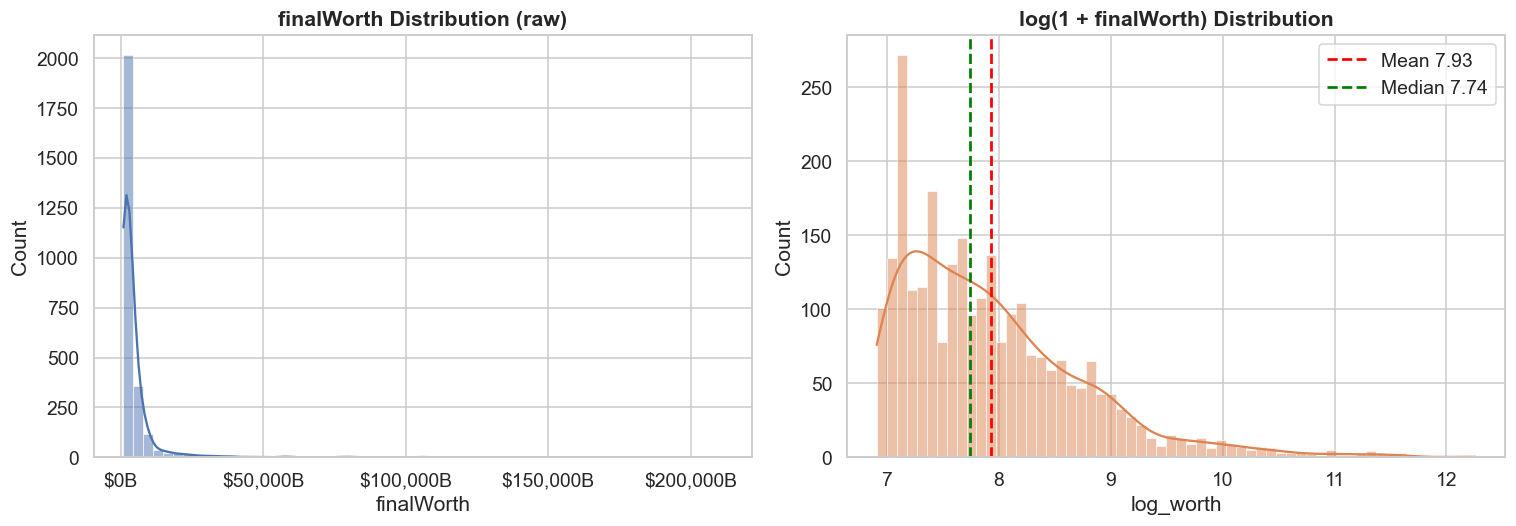

Skewness raw: 10.01  |  log-transformed: 1.32


In [6]:
fig = wealth_distribution(df, save_path=FIGURES_DIR / "01_wealth_dist.png")
plt.show()
print(f"Skewness raw: {df['finalWorth'].skew():.2f}  |  "
      f"log-transformed: {df['log_worth'].skew():.2f}")


## 4. Category, Gender & Self-Made Analysis

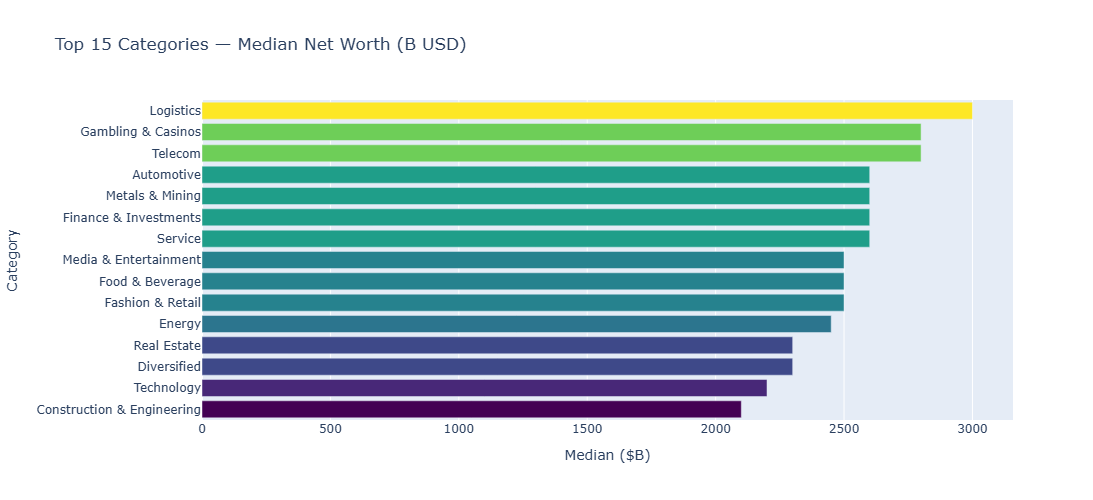

In [7]:
top_categories(df).show()


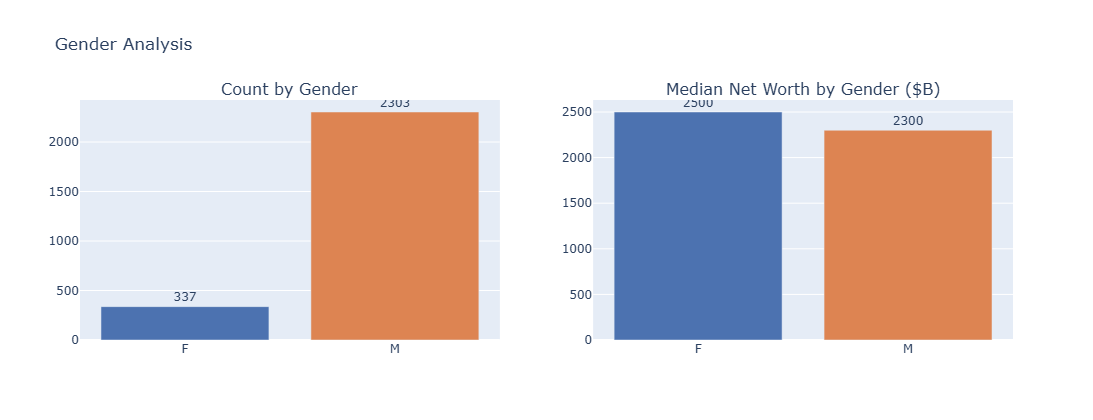

In [8]:
gender_breakdown(df).show()


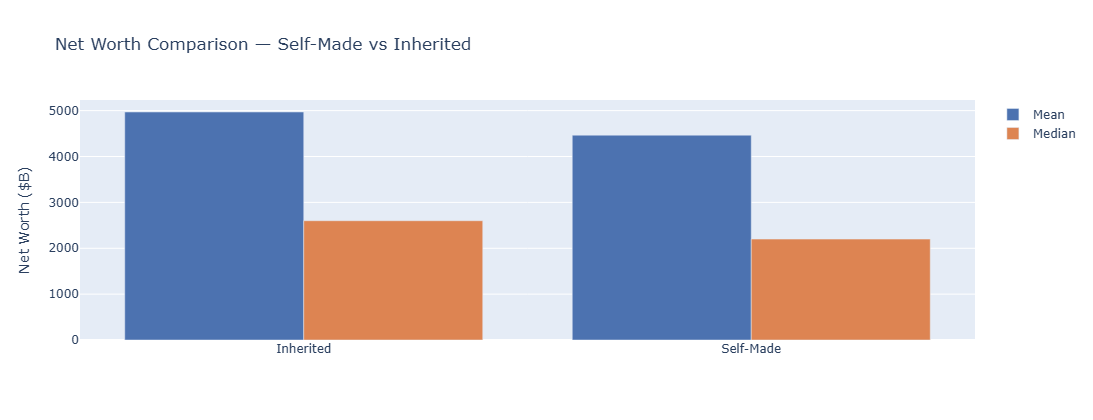

In [9]:
self_made_comparison(df).show()


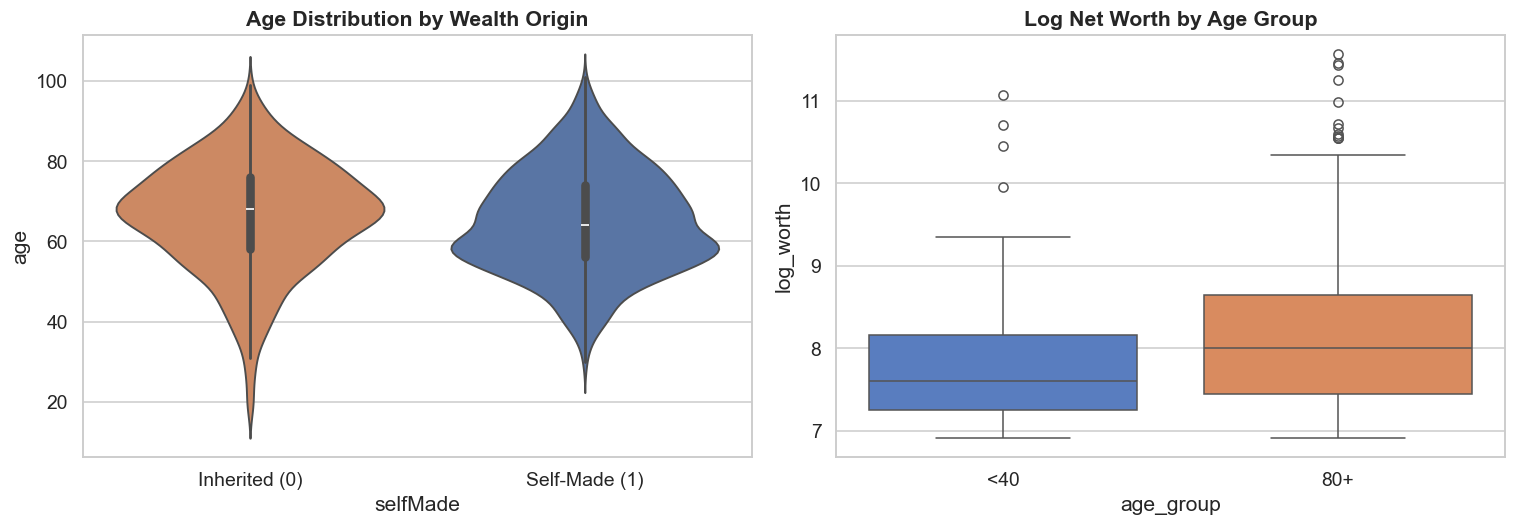

In [10]:
fig = age_distribution(df, save_path=FIGURES_DIR / "02_age_dist.png")
plt.show()


## 5. Correlation

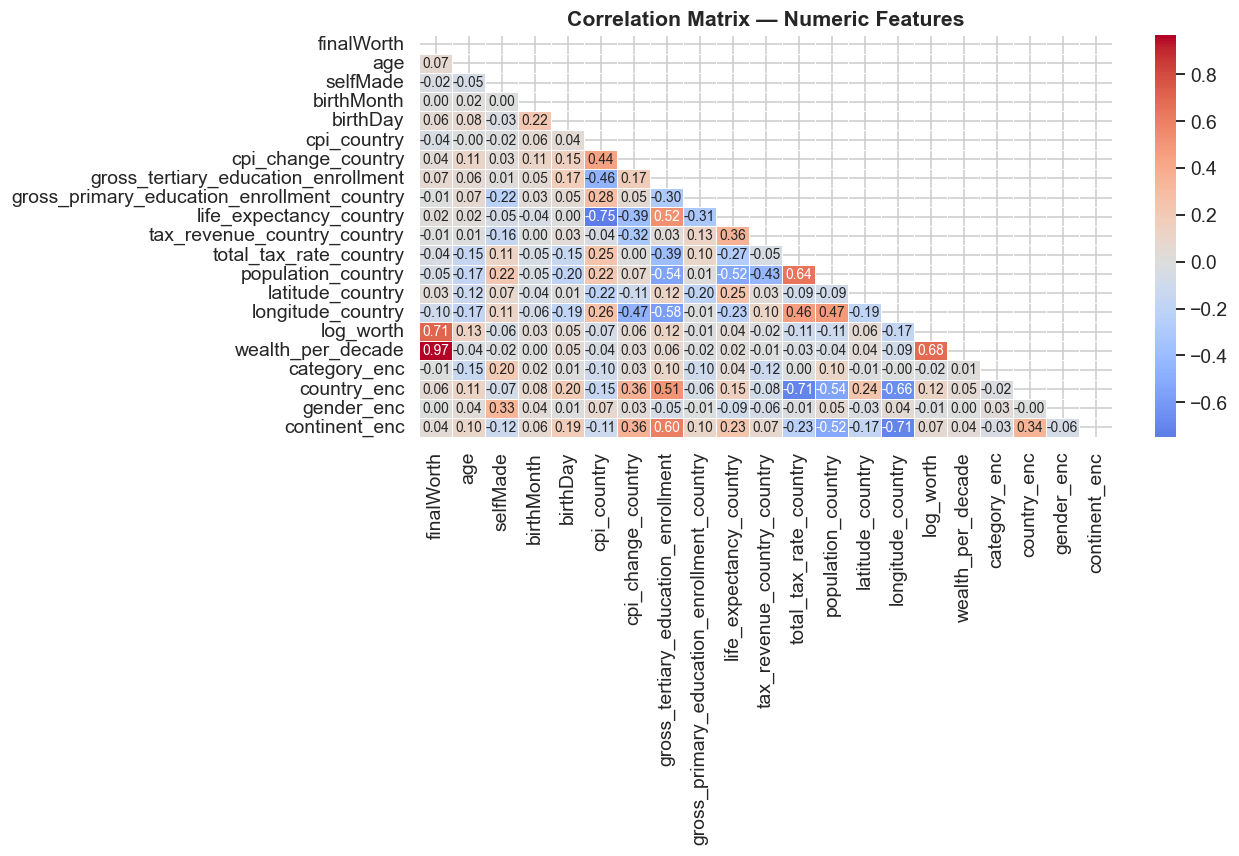

In [11]:
fig = correlation_heatmap(df, save_path=FIGURES_DIR / "03_corr.png")
plt.show()


## 6. Statistical Hypothesis Tests

In [12]:
print("━" * 55)
print("TEST 1 — t-test: Self-Made vs Inherited Net Worth")
print("━" * 55)
sm  = df[df["selfMade"] == 1]["finalWorth"]
inh = df[df["selfMade"] == 0]["finalWorth"]
lev_p = stats.levene(sm, inh).pvalue
equal_var = lev_p > 0.05
t, p = ttest_ind(sm, inh, equal_var=equal_var)
print(f"Levene p={lev_p:.4f}  equal_var={equal_var}")
print(f"t={t:.3f}  p={p:.6f}")
print("→", "Significant" if p < 0.05 else "Not significant", "at α=0.05")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TEST 1 — t-test: Self-Made vs Inherited Net Worth
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Levene p=0.3763  equal_var=True
t=-1.224  p=0.220940
→ Not significant at α=0.05


In [13]:
print("━" * 55)
print("TEST 2 — ANOVA: Net Worth across top 8 categories")
print("━" * 55)
top8   = df["category"].value_counts().head(8).index
groups = [df[df["category"] == c]["finalWorth"].values for c in top8]
f, p   = f_oneway(*groups)
print(f"F={f:.3f}  p={p:.6f}")
print("→", "Means differ" if p < 0.05 else "No difference", "across categories")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TEST 2 — ANOVA: Net Worth across top 8 categories
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
F=4.456  p=0.000062
→ Means differ across categories


In [14]:
print("━" * 55)
print("TEST 3 — Chi-squared: Gender × Self-Made")
print("━" * 55)
ct = pd.crosstab(df["gender"], df["selfMade"])
chi2, p, dof, _ = chi2_contingency(ct)
print(ct)
print(f"\nchi2={chi2:.3f}  p={p:.4f}  dof={dof}")
print("→", "Dependent" if p < 0.05 else "Independent")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TEST 3 — Chi-squared: Gender × Self-Made
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
selfMade    0     1
gender             
F         241    96
M         587  1716

chi2=287.150  p=0.0000  dof=1
→ Dependent


## 7. Wealth Inequality — Gini & Lorenz

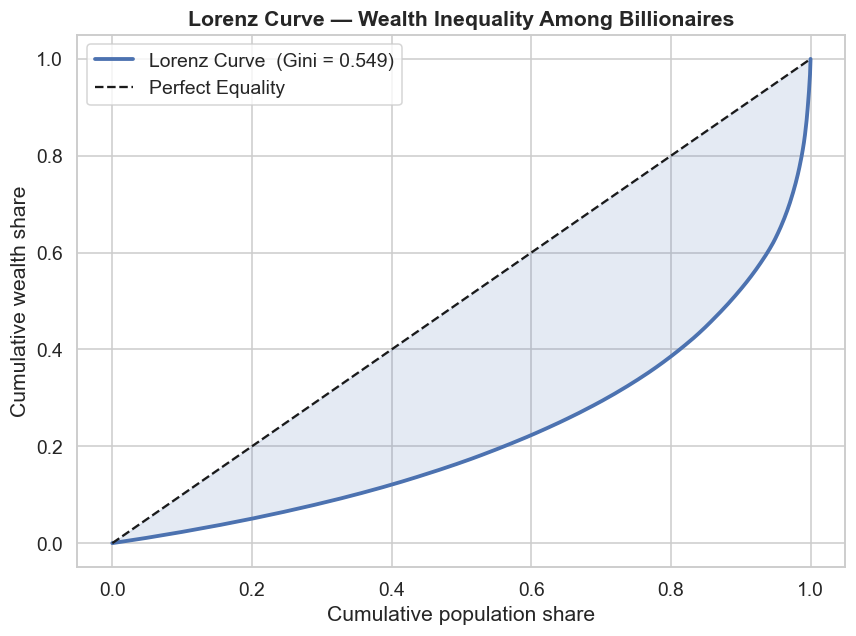

Top  1% share: 18.0%
Top 10% share: 47.8%


In [15]:
fig = lorenz_curve(df, save_path=FIGURES_DIR / "04_lorenz.png")
plt.show()

# Concentration
p99 = df["finalWorth"].quantile(0.99)
p90 = df["finalWorth"].quantile(0.90)
total = df["finalWorth"].sum()
print(f"Top  1% share: {df[df['finalWorth']>=p99]['finalWorth'].sum()/total*100:.1f}%")
print(f"Top 10% share: {df[df['finalWorth']>=p90]['finalWorth'].sum()/total*100:.1f}%")


## 8. Geospatial

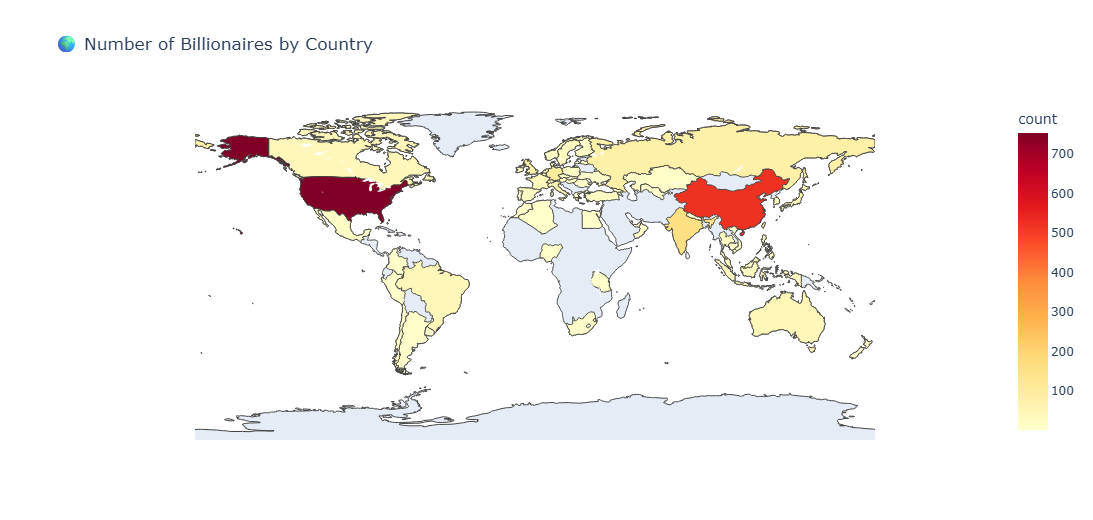

In [16]:
choropleth_count(df).show()


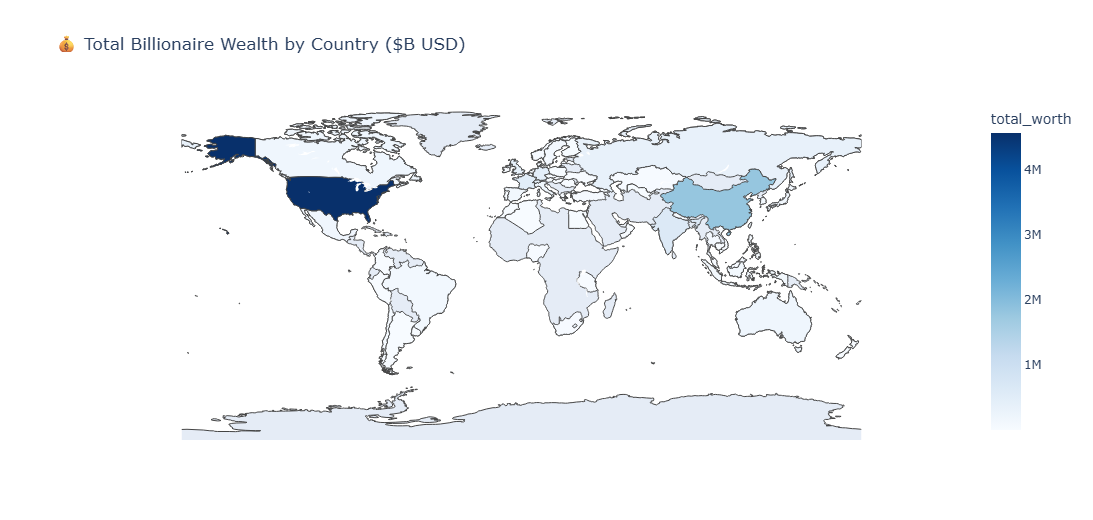

In [17]:
choropleth_wealth(df).show()
